In [1]:
import chess
import torch

# Detecta GPU automaticamente; todos os tensores serão movidos para este device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

# Ordem fixa: brancas (P N B R Q K) nas camadas 0-5, pretas (p n b r q k) nas camadas 6-11
PIECE_TYPES = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]

def board_to_tensor(board: chess.Board) -> torch.Tensor:
    """
    Converte um chess.Board em um tensor (12, 8, 8) pronto para GPU.
    Camadas 0-5  → peças brancas (P, N, B, R, Q, K)
    Camadas 6-11 → peças pretas  (p, n, b, r, q, k)
    Valor 1.0 onde a peça está presente, 0.0 caso contrário.
    """
    tensor = torch.zeros(12, 8, 8, dtype=torch.float32)

    for color_idx, color in enumerate([chess.WHITE, chess.BLACK]):
        for piece_idx, piece_type in enumerate(PIECE_TYPES):
            layer = color_idx * 6 + piece_idx
            for square in board.pieces(piece_type, color):
                row = chess.square_rank(square)  # 0 = rank 1, 7 = rank 8
                col = chess.square_file(square)  # 0 = file a, 7 = file h
                tensor[layer, row, col] = 1.0

    return tensor.to(device)


# --- Teste rápido ---
board = chess.Board()  # posição inicial
t = board_to_tensor(board)
print(f"Shape : {t.shape}")   # esperado: torch.Size([12, 8, 8])
print(f"Device: {t.device}")  # esperado: cuda:0  (ou cpu se não houver GPU)
print(f"Peões brancos (camada 0):\n{t[0]}")   # linha 1 (rank 2) deve ser tudo 1s
print(f"Peões pretos  (camada 6):\n{t[6]}")   # linha 6 (rank 7) deve ser tudo 1s


Usando device: cuda
Shape : torch.Size([12, 8, 8])
Device: cuda:0
Peões brancos (camada 0):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')
Peões pretos  (camada 6):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')


In [2]:
import torch.nn as nn
from pathlib import Path

# ── ResidualBlock — idêntico ao projeto anterior ──────────────────────────────
class ResidualBlock(nn.Module):
    """
    Duas Conv2d 3x3 (padding=1, stride=1 → preserva 8x8) com BatchNorm e
    skip connection. Projeção 1x1 automática quando in_channels != out_channels.
    """
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.dropout  = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


# ── ChessResNetDQN ────────────────────────────────────────────────────────────
class ChessResNetDQN(nn.Module):
    """
    Backbone ResNet (mesmo do projeto anterior) + cabeça de Q-value para DQN.

    Entrada : (batch, 12, 8, 8) — saída de board_to_tensor()
    Saída   : (batch,)          — Q-value escalar por estado

    Diferença em relação ao ChessEvalResNet supervisionado:
      · in_channels=12 em vez de 15 (sem os canais de turno e roque)
      · Módulo da cabeça mantém o nome "head" para maximizar o warm start
        (as chaves do state_dict batem com o checkpoint treinado)
    """
    def __init__(
        self,
        in_channels    = 12,
        stem_channels  = 64,
        block_channels = (64, 128, 128, 256),
        hidden_dim     = 256,
        dropout        = 0.3,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, stem_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.ReLU(inplace=True),
        )

        blocks, prev = [], stem_channels
        for out_ch in block_channels:
            blocks.append(ResidualBlock(prev, out_ch, dropout=dropout * 0.5))
            prev = out_ch
        self.res_blocks = nn.Sequential(*blocks)

        self.gap = nn.AdaptiveAvgPool2d(1)  # (C, 8, 8) → (C, 1, 1)

        # Nome "head" propositalmente idêntico ao projeto anterior
        # para que os pesos carreguem direto do checkpoint
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(prev, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),  # Q-value escalar
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res_blocks(x)
        x = self.gap(x)
        return self.head(x).squeeze(-1)   # (batch, 1) → (batch,)


# ── Warm Start ────────────────────────────────────────────────────────────────
CHECKPOINT = Path("best_model_resnet.pt")

dqn_net = ChessResNetDQN(in_channels=12).to(device)

pretrained_sd = torch.load(CHECKPOINT, map_location=device, weights_only=True)
model_sd      = dqn_net.state_dict()

# Filtra chaves com shape incompatível antes de chamar load_state_dict.
# strict=False sozinho ignora chaves ausentes/extras, mas ainda lança erro
# em mismatches de shape — por isso o filtro manual é necessário aqui.
compatible   = {k: v for k, v in pretrained_sd.items()
                if k in model_sd and v.shape == model_sd[k].shape}
incompatible = [k for k in pretrained_sd if k not in compatible]

dqn_net.load_state_dict(compatible, strict=False)

# ── Relatório de carregamento ─────────────────────────────────────────────────
total_params = sum(p.numel() for p in dqn_net.parameters())
cold_params  = sum(
    p.numel() for name, p in dqn_net.named_parameters()
    if any(name.startswith(k.split(".")[0]) and name in
           {k2 for k2 in model_sd if k2 not in compatible}
           for k in incompatible)
)
# Conta parâmetros cold via nomes excluídos do compatible
cold_names = {k for k in model_sd if k not in compatible}
cold_params = sum(p.numel() for name, p in dqn_net.named_parameters()
                  if name in cold_names)
warm_params = total_params - cold_params

print("=== Warm Start — Relatório ===")
print(f"Checkpoint       : {CHECKPOINT}")
print(f"Chaves carregadas: {len(compatible)}/{len(pretrained_sd)}")
if incompatible:
    print(f"Shape incompatível (reinicializados): {incompatible}")
print(f"\nParâmetros totais    : {total_params:,}")
print(f"  Warm-started       : {warm_params:,}  ({100*warm_params/total_params:.1f}%)")
print(f"  Reinicializados    : {cold_params:,}  ({100*cold_params/total_params:.1f}%)")

# Sugestão: congele o backbone nas primeiras épocas de RL para estabilizar
# o treino — o stem reinicializado ainda está ruidoso nesse momento.
# Descomente se quiser esse comportamento:
# for name, param in dqn_net.named_parameters():
#     if not name.startswith("head"):
#         param.requires_grad = False

dqn_net.train()   # modo treino para as camadas Dropout/BN
print(f"\n{dqn_net}")
n_treinaveis = sum(p.numel() for p in dqn_net.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_treinaveis:,}")


=== Warm Start — Relatório ===
Checkpoint       : best_model_resnet.pt
Chaves carregadas: 71/72
Shape incompatível (reinicializados): ['stem.0.weight']

Parâmetros totais    : 1,624,449
  Warm-started       : 1,617,537  (99.6%)
  Reinicializados    : 6,912  (0.4%)

ChessResNetDQN(
  (stem): Sequential(
    (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (dropout): Dropout2d(p=0.

### 3. Loop de Treinamento — Self-Play por DQN

Com a arquitetura definida, passo agora ao **treinamento por Aprendizado por Reforço** usando *self-play*: o modelo joga contra si mesmo como brancas e como pretas, sem nenhum supervisor humano — apenas o resultado das partidas e o saldo de material guiam o aprendizado.

A formulação segue o **Deep Q-Network (DQN)**, adaptada para um jogo de dois jogadores de soma zero. Em vez do $Q(s, a)$ clássico (um valor por par estado-ação), trato a rede como uma **função de valor de estado** $Q(s)$: para escolher um lance, avalio cada posição resultante $s'$ e seleciono o lance que maximiza $Q(s')$ pelas brancas (ou minimiza pelas pretas). Isso é equivalente ao *policy improvement greedy* no espaço de lances legais — e aproveita diretamente o backbone ResNet já aquecido pelo treinamento supervisionado.

**Componentes essenciais do DQN.**
- **Replay Buffer**: armazena transições $(s,\, s',\, r,\, \text{done})$ e amostra mini-batches aleatórios, quebrando a correlação temporal entre lances consecutivos — sem isso, o DQN diverge;
- **Target Network**: cópia congelada da rede principal usada para calcular o alvo de Bellman. Sem ela, estaríamos "perseguindo um alvo em movimento" a cada passo de gradiente, o que é a principal causa de instabilidade no DQN original;
- **$\varepsilon$-greedy com decaimento**: começa explorando 100% aleatório e reduz gradualmente até 5%, garantindo que o buffer seja populado com diversidade antes da rede assumir o controle da política.

#### 3.1 Hiperparâmetros e Componentes

In [4]:
import random
from collections import deque
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from tqdm.auto import tqdm

# ── Hiperparâmetros ────────────────────────────────────────────────────────────
N_GAMES          = 15_000   # total de partidas de self-play
MAX_PLIES        = 400     # limite de meios-lances por partida (200 lances completos)
GAMMA            = 0.99    # fator de desconto temporal
EPSILON_START    = 1.0     # exploração inicial (100% aleatório)
EPSILON_END      = 0.05    # piso de exploração
EPSILON_DECAY    = 0.9990  # fator multiplicativo por partida — atinge 0.05 ~game 3000
LR               = 1e-4
BATCH_SIZE       = 64
BUFFER_CAPACITY  = 50_000  # capacidade máxima do replay buffer
MIN_BUFFER       = 2_000   # aguarda N transições antes de começar o treino
TARGET_UPDATE    = 100     # copia pesos para a target net a cada N partidas
CHECKPOINT_EVERY = 1000     # salva checkpoint a cada N partidas
CHECKPOINT_DIR   = Path("dqn_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)


# ── Replay Buffer ──────────────────────────────────────────────────────────────
class ReplayBuffer:
    """Buffer circular de tamanho fixo. Transições salvas na CPU para não saturar VRAM."""

    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state: torch.Tensor, next_state: torch.Tensor,
             reward: float, done: bool):
        self.buffer.append((state.cpu(), next_state.cpu(), float(reward), float(done)))

    def sample(self, batch_size: int):
        batch                              = random.sample(self.buffer, batch_size)
        states, next_states, rewards, dones = zip(*batch)
        return (
            torch.stack(states).to(device),
            torch.stack(next_states).to(device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(dones,   dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


# ── Componentes de treino ──────────────────────────────────────────────────────
replay_buffer = ReplayBuffer(BUFFER_CAPACITY)
epsilon       = EPSILON_START

# Target network: cópia congelada da rede principal para estabilizar o alvo Bellman
target_net = ChessResNetDQN(in_channels=12).to(device)
target_net.load_state_dict(dqn_net.state_dict())
target_net.eval()

optimizer_rl = torch.optim.Adam(dqn_net.parameters(), lr=LR)

print("Setup concluído.")
print(f"  Partidas      : {N_GAMES:,}")
print(f"  Epsilon       : {EPSILON_START} → {EPSILON_END}  (decay={EPSILON_DECAY})")
print(f"  Replay buffer : capacidade {BUFFER_CAPACITY:,}  |  treino começa em {MIN_BUFFER:,} transições")
print(f"  Target update : a cada {TARGET_UPDATE} partidas")
print(f"  Checkpoints   : {CHECKPOINT_DIR}/  (a cada {CHECKPOINT_EVERY} partidas)")


Setup concluído.
  Partidas      : 15,000
  Epsilon       : 1.0 → 0.05  (decay=0.999)
  Replay buffer : capacidade 50,000  |  treino começa em 2,000 transições
  Target update : a cada 100 partidas
  Checkpoints   : dqn_checkpoints/  (a cada 1000 partidas)


#### 3.2 Reward Shaping por Material

O problema com recompensas esparsas ($+1 / -1$ apenas no desfecho final) é que, em uma partida de xadrez com dezenas ou centenas de lances, o sinal de reforço demora muito para propagar de volta até os primeiros lances — o crédito se dilui e a rede não aprende o que tornou uma posição boa ou ruim durante a partida. Na prática, isso se manifesta exatamente como o comportamento observado: o modelo converge para **empates rápidos**, pois qualquer sequência de lances que não termine em derrota é igualmente "boa" do ponto de vista do sinal de recompensa.

A solução clássica é o **Reward Shaping**: complementar a recompensa terminal com um sinal **denso** a cada lance, baseado em conhecimento de domínio. Aqui uso a **variação do saldo de material**, sempre sob a perspectiva das brancas:

$$r_{\text{material}}(t) = \text{material}(s_t) - \text{material}(s_{t-1})$$

onde $\text{material}(s) = \sum_{\text{peças brancas}} v_p - \sum_{\text{peças pretas}} v_p$, com os valores clássicos:

| Peça | Valor |
|------|-------|
| Peão ($P$/$p$) | 1 |
| Cavalo ($N$/$n$) | 3 |
| Bispo ($B$/$b$) | 3 |
| Torre ($R$/$r$) | 5 |
| Dama ($Q$/$q$) | 9 |

Quando as brancas capturam uma peça, o saldo sobe e $r_{\text{material}} > 0$; quando as pretas capturam, o saldo cai e $r_{\text{material}} < 0$. Isso gera um sinal de reforço imediato e proporcional ao valor da captura, guiando a rede a preferir posições materialmente vantajosas a cada lance — em vez de simplesmente não perder.

A recompensa total por transição é a soma das duas componentes:

$$r_{\text{total}} = r_{\text{material}}(t) + r_{\text{terminal}}$$

A escala do desfecho final foi ajustada para $r_{\text{terminal}} \in \{+10,\ 0,\ -10\}$ — ligeiramente superior à captura da dama ($+9$) — para que **vencer a partida continue sendo o objetivo dominante** mesmo depois de acumular vantagem material.

#### 3.3 Loop Principal de Self-Play

In [5]:
# ── Material e Reward Shaping ──────────────────────────────────────────────────
MATERIAL_VALUES = {
    chess.PAWN:   1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK:   5,
    chess.QUEEN:  9,
    chess.KING:   0,
}

def material_score(board: chess.Board) -> float:
    """Saldo de material do ponto de vista das brancas (positivo = vantagem branca)."""
    score = 0.0
    for piece in board.piece_map().values():
        val = MATERIAL_VALUES[piece.piece_type]
        score += val if piece.color == chess.WHITE else -val
    return score


# ── Funções auxiliares ─────────────────────────────────────────────────────────

@torch.no_grad()
def select_action(board: chess.Board, eps: float) -> chess.Move:
    """
    Epsilon-greedy sobre Q-values dos estados resultantes de cada lance legal.

    Perspectiva fixa: Q(s) representa a vantagem das brancas.
      · Brancas  → maximiza Q(s')
      · Pretas   → minimiza Q(s')   (adversarial)
    """
    legal = list(board.legal_moves)
    if not legal:
        return None
    if random.random() < eps:
        return random.choice(legal)

    is_white     = (board.turn == chess.WHITE)
    was_training = dqn_net.training
    dqn_net.eval()

    # Avalia todos os estados resultantes em um único forward pass batch
    tensors = []
    for move in legal:
        board.push(move)
        tensors.append(board_to_tensor(board))
        board.pop()

    q_vals = dqn_net(torch.stack(tensors))   # (N,) — um valor por lance

    if was_training:
        dqn_net.train()

    idx = q_vals.argmax().item() if is_white else q_vals.argmin().item()
    return legal[idx]


def train_step() -> tuple:
    """
    Um passo de gradiente DQN com target network.

    Alvo Bellman:  Q_target(s) = r  +  γ · (1 − done) · Q_frozen(s')
    Loss:          MSE(Q(s), Q_target(s))
    """
    if len(replay_buffer) < MIN_BUFFER:
        return None, None

    dqn_net.train()
    states, next_states, rewards, dones = replay_buffer.sample(BATCH_SIZE)

    current_q = dqn_net(states)

    with torch.no_grad():
        target_q = rewards + GAMMA * (1.0 - dones) * target_net(next_states)

    loss = F.mse_loss(current_q, target_q)
    optimizer_rl.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(dqn_net.parameters(), max_norm=1.0)
    optimizer_rl.step()

    return loss.item(), current_q.mean().item()


print("Funções definidas: material_score, select_action, train_step")


# ══════════════════════════════════════════════════════════════════════════════
# ── Loop Principal de Self-Play com Reward Shaping e TensorBoard ──────────────
# ══════════════════════════════════════════════════════════════════════════════

LOG_DIR = f"runs/chess_dqn_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer  = SummaryWriter(log_dir=LOG_DIR)
print(f"\nTensorBoard iniciado. Visualize com:")
print(f"  tensorboard --logdir {LOG_DIR}\n")

global_step = 0
epsilon     = EPSILON_START

try:
    pbar = tqdm(range(1, N_GAMES + 1), desc="Self-play DQN", unit="partida")

    for game_idx in pbar:
        board      = chess.Board()
        game_loss  = []
        game_qvals = []

        # ── Self-play: o modelo joga contra si mesmo ──────────────────────
        while not board.is_game_over() and len(board.move_stack) < MAX_PLIES:

            state      = board_to_tensor(board)
            mat_before = material_score(board)        # saldo antes do lance
            move       = select_action(board, epsilon)

            board.push(move)
            next_state = board_to_tensor(board)

            # ── Reward Shaping: ±valor da peça capturada neste lance ──────
            mat_after  = material_score(board)
            r_material = mat_after - mat_before       # 0 se nenhuma captura

            # ── Recompensa terminal — escala ×10 supera a captura da dama ─
            done       = board.is_game_over() or (len(board.move_stack) >= MAX_PLIES)
            r_terminal = 0.0
            if board.is_game_over():
                result     = board.result()
                r_terminal = 10.0 if result == "1-0" else (-10.0 if result == "0-1" else 0.0)

            reward = r_material + r_terminal

            replay_buffer.push(state, next_state, reward, done)

            loss_val, q_mean = train_step()
            if loss_val is not None:
                game_loss.append(loss_val)
                game_qvals.append(q_mean)
                writer.add_scalar("Train/Loss",         loss_val, global_step)
                writer.add_scalar("Train/Mean_Q_Value", q_mean,   global_step)
                global_step += 1

        # ── Fim de partida ─────────────────────────────────────────────────
        result_str  = board.result() if board.is_game_over() else "1/2-1/2"
        game_length = len(board.move_stack)
        epsilon     = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # ── TensorBoard: métricas por partida ─────────────────────────────
        writer.add_scalar("Game/Epsilon",      epsilon,     game_idx)
        writer.add_scalar("Game/Length_Plies", game_length, game_idx)
        writer.add_scalars(
            "Game/Resultado",
            {
                "Brancas_vencem": float(result_str == "1-0"),
                "Pretas_vencem":  float(result_str == "0-1"),
                "Empate":         float(result_str not in ("1-0", "0-1")),
            },
            game_idx,
        )
        if game_loss:
            writer.add_scalar("Game/Avg_Loss",    sum(game_loss)  / len(game_loss),  game_idx)
            writer.add_scalar("Game/Avg_Q_Value", sum(game_qvals) / len(game_qvals), game_idx)

        # ── Target network (hard update) ───────────────────────────────────
        if game_idx % TARGET_UPDATE == 0:
            target_net.load_state_dict(dqn_net.state_dict())

        # ── Checkpoint completo (modelo + otimizador + estado do treino) ───
        if game_idx % CHECKPOINT_EVERY == 0:
            ckpt = CHECKPOINT_DIR / f"dqn_{game_idx:05d}.pt"
            torch.save({
                "game":        game_idx,
                "model":       dqn_net.state_dict(),
                "optimizer":   optimizer_rl.state_dict(),
                "epsilon":     epsilon,
                "global_step": global_step,
            }, ckpt)
            tqdm.write(f"  [Checkpoint] {ckpt}")

        pbar.set_postfix(
            eps    = f"{epsilon:.4f}",
            result = result_str,
            plies  = game_length,
            buffer = f"{len(replay_buffer):,}",
            loss   = f"{game_loss[-1]:.4f}" if game_loss else "N/A",
        )

except KeyboardInterrupt:
    print("\nTreino interrompido pelo usuário. Estado atual preservado.")

finally:
    writer.close()
    print(f"\nTreinamento encerrado.")
    print(f"  Partidas concluídas  : {game_idx:,} / {N_GAMES:,}")
    print(f"  Passos de treino     : {global_step:,}")
    print(f"  Transições no buffer : {len(replay_buffer):,}")
    print(f"  Logs TensorBoard     : {LOG_DIR}")
    print(f"\nPara visualizar: tensorboard --logdir {LOG_DIR}")


Funções definidas: material_score, select_action, train_step

TensorBoard iniciado. Visualize com:
  tensorboard --logdir runs/chess_dqn_20260623_102340



Self-play DQN:   7%|▋         | 1000/15000 [28:42<6:09:10,  1.58s/partida, buffer=50,000, eps=0.3677, loss=31.4411, plies=293, result=1/2-1/2]

  [Checkpoint] dqn_checkpoints/dqn_01000.pt


Self-play DQN:  13%|█▎        | 2000/15000 [54:18<5:51:40,  1.62s/partida, buffer=50,000, eps=0.1352, loss=8.4340, plies=302, result=1/2-1/2]  

  [Checkpoint] dqn_checkpoints/dqn_02000.pt


...

  [Checkpoint] dqn_checkpoints/dqn_13000.pt


Self-play DQN:  93%|█████████▎| 14000/15000 [5:00:29<19:47,  1.19s/partida, buffer=50,000, eps=0.0500, loss=0.3398, plies=33, result=1/2-1/2]   

  [Checkpoint] dqn_checkpoints/dqn_14000.pt


Self-play DQN: 100%|██████████| 15000/15000 [5:24:38<00:00,  1.30s/partida, buffer=50,000, eps=0.0500, loss=1.1121, plies=58, result=1/2-1/2] 

  [Checkpoint] dqn_checkpoints/dqn_15000.pt

Treinamento encerrado.
  Partidas concluídas  : 15,000 / 15,000
  Passos de treino     : 2,574,091
  Transições no buffer : 50,000
  Logs TensorBoard     : runs/chess_dqn_20260623_102340

Para visualizar: tensorboard --logdir runs/chess_dqn_20260623_102340


### 4. Visualização do Treinamento

Uma ressalva importante antes dos gráficos: o `SummaryWriter` registrou métricas **por passo de gradiente** (mais de 2,5 milhões de pontos) em `runs/chess_dqn_20260623_102340/`, mas esse treino rodou no Colab e os logs completos do TensorBoard não foram baixados/preservados neste repositório — só os *outputs* já salvos deste notebook sobreviveram, e eles só contêm o que a barra de progresso imprimiu a cada 1000 partidas (15 pontos no total, já visíveis na célula 3.3 acima). Por isso os gráficos abaixo têm uma granularidade bem mais grossa do que as curvas de época da CNN/ResNet em `projeto.ipynb` — e o valor de `loss` em cada ponto é a **loss de um único minibatch** (o último passo de gradiente daquela partida), não uma média suavizada, então esperamos bem mais ruído do que uma curva de treino tradicional.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

COR_FUNDO_EXTERNO = '#F1F2D8'
COR_FUNDO_INTERNO = '#312F2B'

# Dados extraídos dos checkpoints impressos durante o treino real (barra de progresso
# salva nos outputs da célula 3.3). Um ponto a cada 1000 partidas -- ver ressalva acima.
historico_treino = [
    {'partida': 1000,  'epsilon': 0.3677, 'loss': 31.4411, 'plies': 293},
    {'partida': 2000,  'epsilon': 0.1352, 'loss': 8.4340,  'plies': 302},
    {'partida': 3000,  'epsilon': 0.0500, 'loss': 5.4958,  'plies': 156},
    {'partida': 4000,  'epsilon': 0.0500, 'loss': 4.3702,  'plies': 167},
    {'partida': 5000,  'epsilon': 0.0500, 'loss': 3.5549,  'plies': 247},
    {'partida': 6000,  'epsilon': 0.0500, 'loss': 2.8851,  'plies': 215},
    {'partida': 7000,  'epsilon': 0.0500, 'loss': 16.3050, 'plies': 109},
    {'partida': 8000,  'epsilon': 0.0500, 'loss': 2.9799,  'plies': 145},
    {'partida': 9000,  'epsilon': 0.0500, 'loss': 2.8376,  'plies': 323},
    {'partida': 10000, 'epsilon': 0.0500, 'loss': 0.6907,  'plies': 128},
    {'partida': 11000, 'epsilon': 0.0500, 'loss': 0.9658,  'plies': 243},
    {'partida': 12000, 'epsilon': 0.0500, 'loss': 0.9471,  'plies': 163},
    {'partida': 13000, 'epsilon': 0.0500, 'loss': 0.4246,  'plies': 180},
    {'partida': 14000, 'epsilon': 0.0500, 'loss': 0.3398,  'plies': 33},
    {'partida': 15000, 'epsilon': 0.0500, 'loss': 1.1121,  'plies': 58},
]

df_treino = pd.DataFrame(historico_treino)
df_treino

,partida,epsilon,loss,plies
0,1000,0.3677,31.4411,293
1,2000,0.1352,8.4340,302
2,3000,0.0500,5.4958,156
3,4000,0.0500,4.3702,167
4,5000,0.0500,3.5549,247
5,6000,0.0500,2.8851,215
6,7000,0.0500,16.3050,109
7,8000,0.0500,2.9799,145
8,9000,0.0500,2.8376,323
9,10000,0.0500,0.6907,128


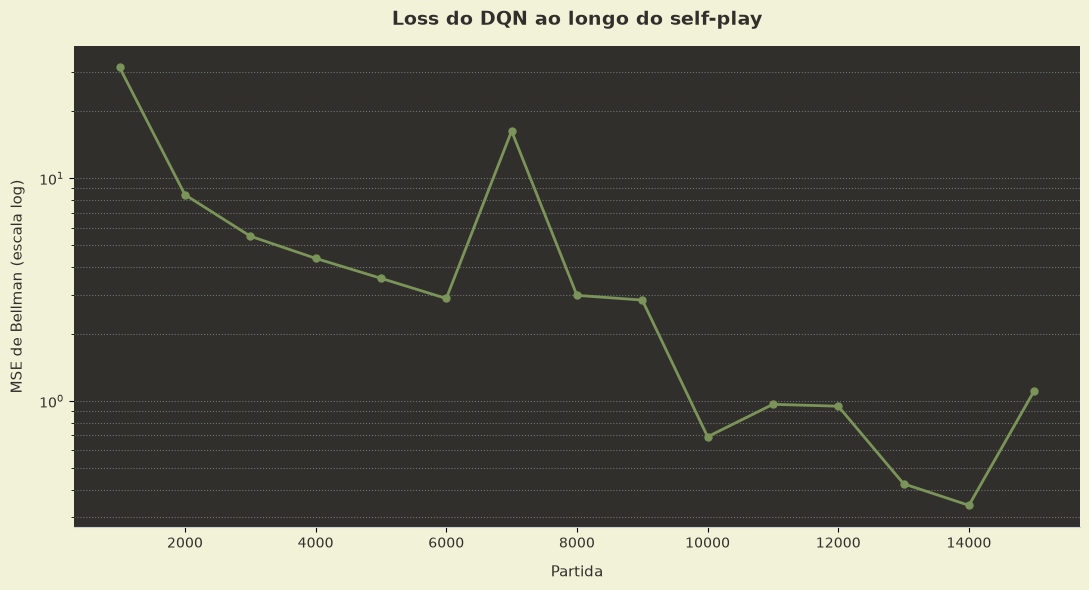

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.plot(df_treino['partida'], df_treino['loss'], color='#7B9459', linewidth=2, marker='o', markersize=5)

ax.set_yscale('log')
ax.set_title('Loss do DQN ao longo do self-play', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Partida', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('MSE de Bellman (escala log)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', which='both', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

plt.tight_layout()
plt.show()

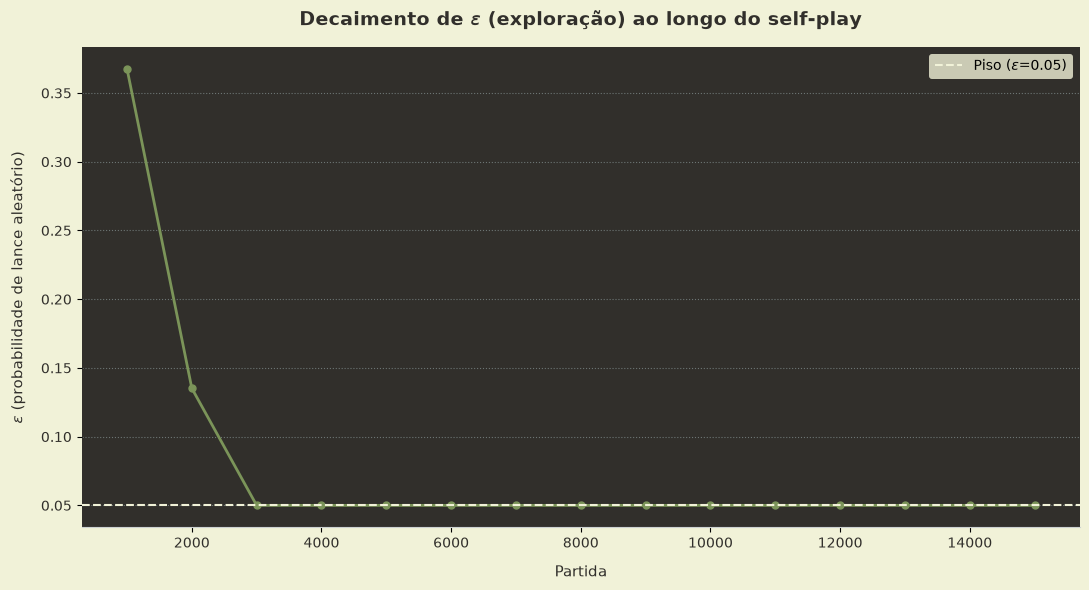

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.plot(df_treino['partida'], df_treino['epsilon'], color='#7B9459', linewidth=2, marker='o', markersize=5)
ax.axhline(EPSILON_END, color=COR_FUNDO_EXTERNO, linestyle='--', linewidth=1.5,
           label=fr'Piso ($\varepsilon$={EPSILON_END})')

ax.set_title(r'Decaimento de $\varepsilon$ (exploração) ao longo do self-play',
             fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Partida', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel(r'$\varepsilon$ (probabilidade de lance aleatório)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')
ax.legend(frameon=True, facecolor=COR_FUNDO_EXTERNO, edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

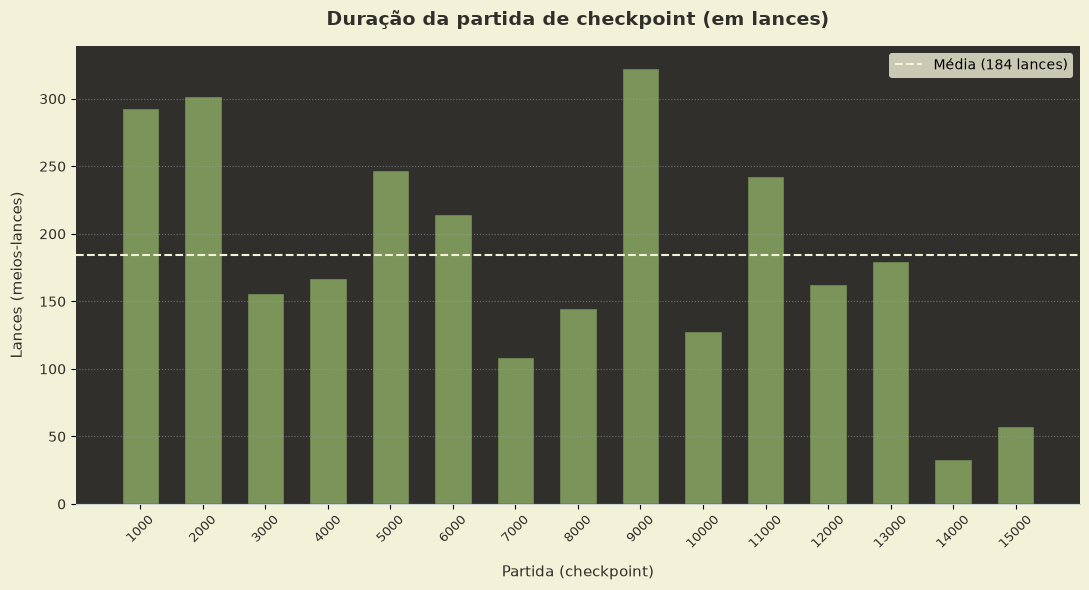

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.bar(df_treino['partida'].astype(str), df_treino['plies'], color='#7B9459', edgecolor=COR_FUNDO_INTERNO, width=0.6)

media_plies = df_treino['plies'].mean()
ax.axhline(media_plies, color=COR_FUNDO_EXTERNO, linestyle='--', linewidth=1.5,
           label=f'Média ({media_plies:.0f} lances)')

ax.set_title('Duração da partida de checkpoint (em lances)', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Partida (checkpoint)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Lances (meios-lances)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=9, labelcolor=COR_FUNDO_INTERNO, rotation=45)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')
ax.legend(frameon=True, facecolor=COR_FUNDO_EXTERNO, edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

#### 4.1 Discussão

**Epsilon** segue exatamente o schedule planejado: cai de 1.0 para o piso de 0.05 por volta da partida 3000 — igual à estimativa feita no comentário dos hiperparâmetros (`EPSILON_DECAY = 0.9990` → "atinge 0.05 ~game 3000"), uma boa checagem de que a implementação bate com o desenho experimental.

**Loss** despenca de 31.4 (partida 1000, ainda sob forte exploração aleatória e replay buffer recém-preenchido) para a casa de 3-5 assim que $\varepsilon$ atinge o piso, e segue caindo até valores abaixo de 1 nas últimas partidas — sinal de que o alvo de Bellman ficou mais previsível conforme a política se estabilizou. O pico isolado em 16.3 na partida 7000 é esperado dado que cada ponto é a loss de **um único minibatch** (não uma média): um lote com transições atípicas (ex.: logo após uma cópia da target network, ou uma sequência de capturas incomuns) é suficiente para produzir esse tipo de espícula, uma característica conhecida de DQN com *hard updates* da target network a cada 100 partidas em vez de atualização suave (*Polyak averaging*).

**Duração das partidas** varia bastante (33 a 323 lances) e não decresce de forma monotônica, mas as últimas partidas amostradas (13000-15000) tendem a ser bem mais curtas (180, 33, 58) que as primeiras pós-exploração (156-323) — compatível com o que observamos depois no confronto direto contra a ResNet (`resnet_vs_dqn_part*.json`): quando o DQN está em desvantagem clara, os jogos tendem a se resolver rápido (poucos lances legais, xeque-mate mais cedo). Com apenas 15 amostras espaçadas, porém, essa tendência deve ser lida como sugestiva, não conclusiva — o ideal seria reprocessar os `.tfevents` completos do Colab (se ainda existirem) para uma curva por partida em vez de por checkpoint.